<a href="https://colab.research.google.com/github/srishtiiwalia/Python_WebScraping/blob/main/Stocks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

# Optional settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asadullahcreative/us-stock-market-historical-ohlcv-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'us-stock-market-historical-ohlcv-dataset' dataset.
Path to dataset files: /kaggle/input/us-stock-market-historical-ohlcv-dataset


In [8]:
print("Downloading Dataset from Kaggle")
path = kagglehub.dataset_download("asadullahcreative/us-stock-market-historical-ohlcv-dataset")
print("Dataset downloaded")

csv_filename = "stock_prices_daily.csv"
full_path = os.path.join(path, csv_filename)

df = pd.read_csv(full_path)
print("\n\033[1;4m" + "Shape:" + "\033[0m" + f" {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\n\033[1;4m" + "Dataset Basic Information" + "\033[0m")
print(df.info())

Using Colab cache for faster access to the 'us-stock-market-historical-ohlcv-dataset' dataset.
Dataset downloaded

Shape: 184,138 rows × 11 columns

Dataset Basic Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184138 entries, 0 to 184137
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          184138 non-null  object 
 1   Ticker        184138 non-null  object 
 2   Company_Name  184138 non-null  object 
 3   Sector        184138 non-null  object 
 4   Industry      184138 non-null  object 
 5   Open          184138 non-null  float64
 6   High          184138 non-null  float64
 7   Low           184138 non-null  float64
 8   Close         184138 non-null  float64
 9   Adj_Close     184138 non-null  float64
 10  Volume        184138 non-null  int64  
dtypes: float64(5), int64(1), object(5)
memory usage: 15.5+ MB
None


/tmp/ipykernel_6980/2659330010.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Sector', order=df['Sector'].value_counts().index, palette='viridis')


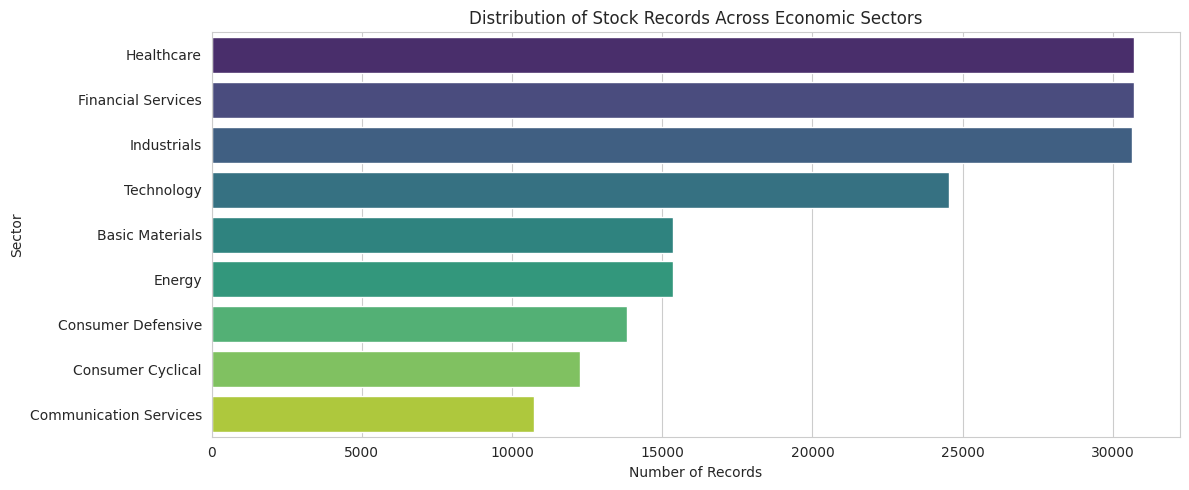

In [9]:
if 'Sector' in df.columns:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, y='Sector', order=df['Sector'].value_counts().index, palette='viridis')
    plt.title('Distribution of Stock Records Across Economic Sectors')
    plt.xlabel('Number of Records')
    plt.ylabel('Sector')
    plt.tight_layout()
    plt.savefig('sector_distribution.png')
    plt.show()

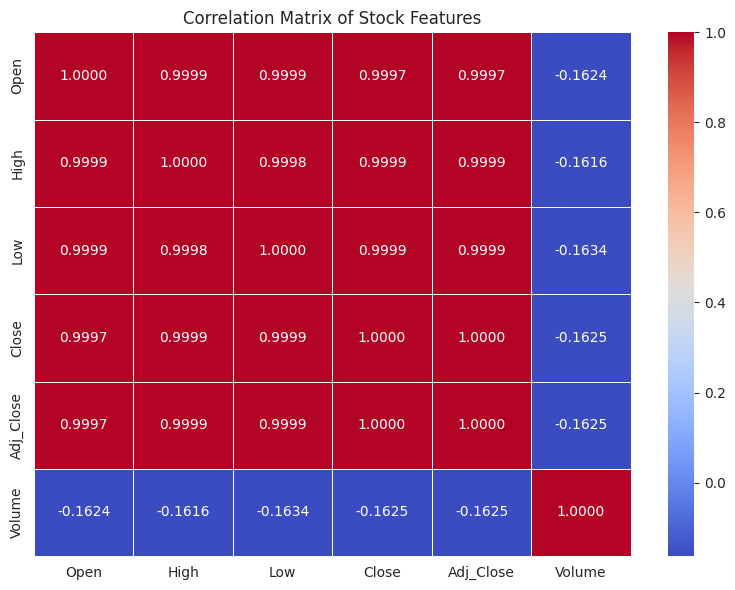

In [10]:
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5)
plt.title('Correlation Matrix of Stock Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

In [11]:
print("NUMBER OF UNIQUE STOCKS")

print(df['Ticker'].nunique())
print()

print("TOP STOCKS")

print(df['Ticker'].value_counts().head())
print()

NUMBER OF UNIQUE STOCKS
120

TOP STOCKS
Ticker
AAPL    1535
ABBV    1535
ABT     1535
ADBE    1535
AIG     1535
Name: count, dtype: int64



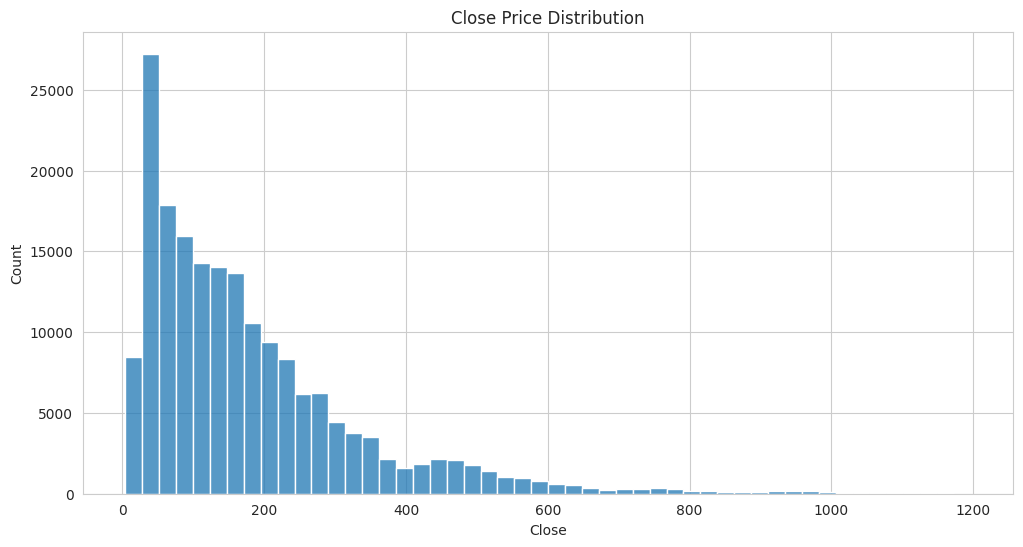

In [12]:
plt.figure(figsize=(12,6))

sns.histplot(df['Close'], bins=50)

plt.title("Close Price Distribution")

plt.show()

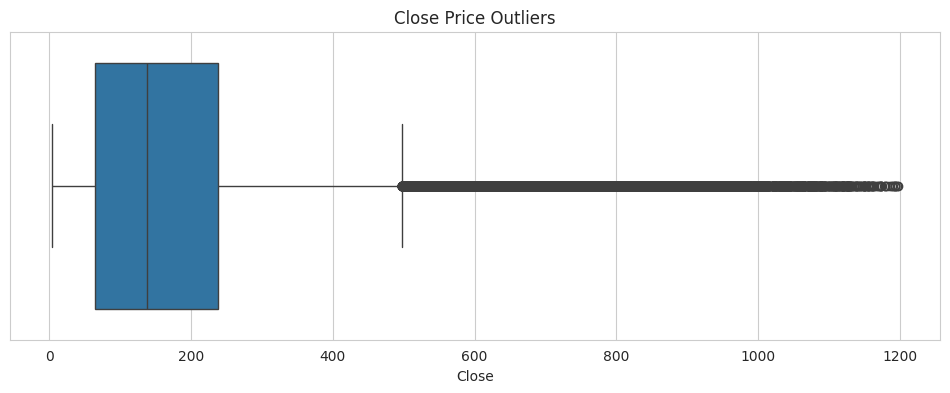

In [13]:
plt.figure(figsize=(12,4))

sns.boxplot(x=df['Close'])

plt.title("Close Price Outliers")

plt.show()


In [14]:
#Pre-processing

import os
import pandas as pd
import numpy as np
import glob

from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [15]:
import kagglehub

path = kagglehub.dataset_download(
    "asadullahcreative/us-stock-market-historical-ohlcv-dataset"
)

print("Dataset Path:", path)


# Find CSV file dynamically (important for KaggleHub)
csv_files = glob.glob(os.path.join(path, "*.csv"))
df = pd.read_csv(csv_files[0])

Using Colab cache for faster access to the 'us-stock-market-historical-ohlcv-dataset' dataset.
Dataset Path: /kaggle/input/us-stock-market-historical-ohlcv-dataset


In [16]:
# Standardize column names
df.columns = df.columns.str.strip()

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Remove duplicates
df = df.drop_duplicates()

# Sort for time-series correctness
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

/tmp/ipykernel_6980/1969088020.py:5: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["Date"] = pd.to_datetime(df["Date"])


In [17]:
# Check missing values
df = df.dropna()

In [18]:
# --- Time features ---
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Drop bad rows if any dates failed parsing
df = df.dropna(subset=["Date"])

# Now safe
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# Time features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek


In [19]:
# 5. TARGET CREATION (NEXT DAY CLOSE)
# ============================================================

df["Target"] = df.groupby("Ticker")["Close"].shift(-1)

In [20]:
# 6. FINAL CLEANING AFTER FEATURE ENGINEERING
# ============================================================

df = df.dropna().reset_index(drop=True)


# ============================================================
# 7. ENCODE CATEGORICAL VARIABLES
# ============================================================

le_ticker = LabelEncoder()
le_sector = LabelEncoder()
le_industry = LabelEncoder()

df["Ticker"] = le_ticker.fit_transform(df["Ticker"])
df["Sector"] = le_sector.fit_transform(df["Sector"])
df["Industry"] = le_industry.fit_transform(df["Industry"])

In [21]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)



In [22]:
# Return
df["Return"] = df.groupby("Ticker")["Close"].pct_change()

# Moving averages
df["MA7"] = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(7).mean())
df["MA21"] = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(21).mean())

# Volatility
df["Volatility"] = df.groupby("Ticker")["Return"].transform(lambda x: x.rolling(7).std())

# Price range
df["Price_Range"] = df["High"] - df["Low"]

In [23]:
df["Target"] = df.groupby("Ticker")["Close"].shift(-1)

In [24]:
df = df.dropna().reset_index(drop=True)

In [25]:
features = [
    "Ticker",
    "Sector",
    "Industry",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Return",
    "MA7",
    "MA21",
    "Volatility",
    "Price_Range"
]

X = df[features]
y = df["Target"]

In [26]:
# ============================================================
# 9. TIME-BASED TRAIN TEST SPLIT
# ============================================================

train_size = int(len(df) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [27]:
# ============================================================
# 10. SCALING (IMPORTANT FOR ML / LSTM)
# ============================================================

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))

In [28]:
# ============================================================
# 11. OUTPUT SHAPES (FINAL CHECK)
# ============================================================

print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)
print("y_train:", y_train_scaled.shape)
print("y_test :", y_test_scaled.shape)

X_train: (49977, 17)
X_test : (12495, 17)
y_train: (49977, 1)
y_test : (12495, 1)


In [29]:
#Model Development

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, accuracy_score, roc_auc_score

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

In [30]:
DATA_PATH = "/kaggle/input/us-stock-market-historical-ohlcv-dataset/"

import os
print(os.listdir(DATA_PATH))

['stock_prices_daily.csv']


In [31]:
df = pd.read_csv(DATA_PATH + "stock_prices_daily.csv")

In [32]:
# =========================
# 3. BASIC FEATURE ENGINEERING
# =========================

# Daily return
df['return'] = df.groupby('Ticker')['Close'].pct_change()

# Target 1: next day return
df['target_return'] = df.groupby('Ticker')['return'].shift(-1)

# Target 2: direction
df['target_dir'] = (df['target_return'] > 0).astype(int)

# Target 3: volatility (future 5-day rolling std)
df['target_vol'] = df.groupby('Ticker')['return'].rolling(5).std().reset_index(0, drop=True)

# =========================
# 4. TECHNICAL INDICATORS
# =========================

def add_features(group):
    group = group.copy()

    group['sma_10'] = group['Close'].rolling(10).mean()
    group['sma_20'] = group['Close'].rolling(20).mean()

    group['ema_10'] = group['Close'].ewm(span=10).mean()

    group['volatility_10'] = group['return'].rolling(10).std()

    return group

df = df.groupby('Ticker').apply(add_features).reset_index(drop=True)

/tmp/ipykernel_6980/509802195.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Ticker').apply(add_features).reset_index(drop=True)


In [33]:
# =========================
# 5. LAG FEATURES
# =========================
for lag in [1, 2, 3, 5]:
    df[f'return_lag_{lag}'] = df.groupby('Ticker')['return'].shift(lag)

# =========================
# 6. CLEAN DATA
# =========================
df = df.dropna()

# =========================
# 7. ENCODE TICKER
# =========================
le = LabelEncoder()
df['Ticker_enc'] = le.fit_transform(df['Ticker'])

# =========================
# 8. FEATURE SET
# =========================
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'return',
    'sma_10', 'sma_20', 'ema_10',
    'volatility_10',
    'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5',
    'Ticker_enc'
]

target_cols = ['target_return', 'target_dir', 'target_vol']

In [34]:
# =========================
# 9. SCALE FEATURES (IMPORTANT: NO LEAKAGE)
# =========================
train_cutoff = int(len(df) * 0.8)

train_df = df.iloc[:train_cutoff]
test_df = df.iloc[train_cutoff:]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

train_targets = train_df[target_cols].values
test_targets = test_df[target_cols].values

# =========================
# 10. SEQUENCE CREATION
# =========================
WINDOW = 30

def create_sequences(X, y, window=30):
    Xs, y_r, y_d, y_v = [], [], [], []

    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        y_r.append(y[i, 0])
        y_d.append(y[i, 1])
        y_v.append(y[i, 2])

    return np.array(Xs), np.array(y_r), np.array(y_d), np.array(y_v)

X_train, ytr_r, ytr_d, ytr_v = create_sequences(train_scaled, train_targets, WINDOW)
X_test, yte_r, yte_d, yte_v = create_sequences(test_scaled, test_targets, WINDOW)

In [35]:
# =========================
# 11. MULTI-TASK LSTM MODEL
# =========================

inputs = tf.keras.Input(shape=(WINDOW, len(feature_cols)))

x = layers.LSTM(128, return_sequences=True)(inputs)
x = layers.Dropout(0.2)(x)

x = layers.LSTM(64)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)

# ---- Return head ----
r = layers.Dense(32, activation='relu')(x)
r = layers.Dense(1, name='return_output')(r)

# ---- Direction head ----
d = layers.Dense(32, activation='relu')(x)
d = layers.Dense(1, activation='sigmoid', name='dir_output')(d)

# ---- Volatility head ----
v = layers.Dense(32, activation='relu')(x)
v = layers.Dense(1, name='vol_output')(v)

model = Model(inputs=inputs, outputs=[r, d, v])

model.compile(
    optimizer='adam',
    loss={
        'return_output': 'mse',
        'dir_output': 'binary_crossentropy',
        'vol_output': 'mse'
    },
    loss_weights={
        'return_output': 1.0,
        'dir_output': 1.5,
        'vol_output': 1.0
    },
    metrics={
        'return_output': 'mae',
        'dir_output': 'accuracy',
        'vol_output': 'mae'
    }
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 15)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 30, 128)   │     73,728 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ return_output       │ (None, 1)         │         33 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dir_output (Dense)  │ (None, 1)         │         33 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vol_output (Dense)  │ (None, 1)         │         33 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 133,635 (522.01 KB)

 Trainable params: 133,635 (522.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================
# 12. TRAINING
# =========================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    {
        'return_output': ytr_r,
        'dir_output': ytr_d,
        'vol_output': ytr_v
    },
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    shuffle=False
)


In [ ]:
#Prediction

pred_r, pred_d, pred_v = model.predict(X_test)

pred_d_bin = (pred_d > 0.5).astype(int)

In [ ]:
#Evaluation

print("Return MAE:", mean_absolute_error(yte_r, pred_r))
print("Direction Accuracy:", accuracy_score(yte_d, pred_d_bin))

try:
    print("ROC-AUC:", roc_auc_score(yte_d, pred_d))
except:
    pass

In [ ]:
#Simple BackTest

strategy_returns = np.where(
    pred_d_bin.flatten() == 1,
    pred_r.flatten(),
    -pred_r.flatten()
)

print("Mean Strategy Return:", np.mean(strategy_returns))
print("Sharpe Ratio:", np.mean(strategy_returns) / (np.std(strategy_returns) + 1e-6))

In [ ]:
import matplotlib.pyplot as plt

# Loss curve
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title("Model Loss Curve")
plt.legend()
plt.show()

# Direction accuracy curve
plt.figure()
plt.plot(history.history['dir_output_accuracy'], label='train acc')
plt.plot(history.history['val_dir_output_accuracy'], label='val acc')
plt.title("Direction Accuracy Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(yte_d, pred_d_bin)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Direction Prediction")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(yte_d, pred_d)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
import numpy as np

strategy_returns = np.where(
    pred_d_bin.flatten() == 1,
    yte_r,
    -yte_r
)

cumulative_returns = np.cumsum(strategy_returns)

plt.figure()
plt.plot(cumulative_returns)
plt.title("Cumulative Strategy Returns")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.show()

In [37]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=47dbd2855938e73c836332b5232ebe17320a1054e7b00fb2dea6528504c5503c
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [38]:
import ta  # pip install ta

def add_features(df):
    # Trend
    df['ema_9']  = ta.trend.EMAIndicator(df['close'], 9).ema_indicator()
    df['ema_21'] = ta.trend.EMAIndicator(df['close'], 21).ema_indicator()
    df['macd']   = ta.trend.MACD(df['close']).macd_diff()
    df['adx']    = ta.trend.ADXIndicator(df['high'], df['low'], df['close']).adx()

    # Momentum
    df['rsi']    = ta.momentum.RSIIndicator(df['close']).rsi()
    df['stoch']  = ta.momentum.StochasticOscillator(df['high'], df['low'], df['close']).stoch()
    df['cci']    = ta.trend.CCIIndicator(df['high'], df['low'], df['close']).cci()

    # Volatility
    bb = ta.volatility.BollingerBands(df['close'])
    df['bb_width'] = bb.bollinger_wband()
    df['bb_pct']   = bb.bollinger_pband()
    df['atr']      = ta.volatility.AverageTrueRange(df['high'], df['low'], df['close']).average_true_range()

    # Volume
    df['obv']    = ta.volume.OnBalanceVolumeIndicator(df['close'], df['volume']).on_balance_volume()
    df['vwap']   = ta.volume.VolumeWeightedAveragePrice(df['high'], df['low'], df['close'], df['volume']).volume_weighted_average_price()

    # Price-derived
    df['log_return']    = np.log(df['close'] / df['close'].shift(1))
    df['hl_range']      = (df['high'] - df['low']) / df['close']
    df['gap']           = (df['open'] - df['close'].shift(1)) / df['close'].shift(1)
    df['realized_vol']  = df['log_return'].rolling(10).std()

    return df.dropna()

In [39]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_model(window, n_features):
    inputs = tf.keras.Input(shape=(window, n_features))

    # --- Shared Encoder ---
    x = layers.LSTM(128, return_sequences=True)(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)

    # --- Temporal Attention ---
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    attn = layers.LayerNormalization()(attn + x)         # residual
    shared = layers.GlobalAveragePooling1D()(attn)

    # --- Task-specific towers ---
    # Direction (classification) — needs sharper features
    d = layers.Dense(64, activation='relu')(shared)
    d = layers.BatchNormalization()(d)
    d = layers.Dropout(0.3)(d)
    d = layers.Dense(32, activation='relu')(d)
    d = layers.Dense(1, activation='sigmoid', name='dir_output')(d)

    # Volatility (regression)
    v = layers.Dense(64, activation='relu')(shared)
    v = layers.BatchNormalization()(v)
    v = layers.Dropout(0.2)(v)
    v = layers.Dense(32, activation='relu')(v)
    v = layers.Dense(1, activation='softplus', name='vol_output')(v)  # softplus keeps vol > 0

    # Return (regression)
    r = layers.Dense(64, activation='relu')(shared)
    r = layers.Dropout(0.2)(r)
    r = layers.Dense(32, activation='relu')(r)
    r = layers.Dense(1, name='return_output')(r)

    model = Model(inputs=inputs, outputs=[r, d, v])
    return model

In [40]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Boost direction weight — it's your primary task
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        'return_output': 'huber',          # more robust than MSE to outliers
        'dir_output':    'binary_crossentropy',
        'vol_output':    'huber'
    },
    loss_weights={
        'return_output': 0.5,
        'dir_output':    2.0,              # prioritise direction
        'vol_output':    1.0
    },
    metrics={
        'return_output': 'mae',
        'dir_output':    ['accuracy', tf.keras.metrics.AUC(name='auc')],
        'vol_output':    'mae'
    }
)

callbacks = [
    EarlyStopping(monitor='val_dir_output_auc', patience=12,
                  restore_best_weights=True, mode='max'),   # monitor AUC not loss
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-5)
]

history = model.fit(
    X_train,
    {'return_output': ytr_r, 'dir_output': ytr_d, 'vol_output': ytr_v},
    validation_split=0.1,
    epochs=100,           # let LR scheduler do the work
    batch_size=32,        # smaller batch → better generalization
    callbacks=callbacks,
    shuffle=False         # CRITICAL: time series — never shuffle
)

Epoch 1/100
4089/4089 ━━━━━━━━━━━━━━━━━━━━ 68s 14ms/step - dir_output_accuracy: 0.5193 - dir_output_auc: 0.5015 - dir_output_loss: 0.6927 - loss: 1.3858 - return_output_loss: 3.5028e-04 - return_output_mae: 0.0174 - vol_output_loss: 1.9520e-04 - vol_output_mae: 0.0125 - val_dir_output_accuracy: 0.5171 - val_dir_output_auc: 0.5000 - val_dir_output_loss: 0.6926 - val_loss: 1.3854 - val_return_output_loss: 2.2095e-04 - val_return_output_mae: 0.0140 - val_vol_output_loss: 8.4056e-05 - val_vol_output_mae: 0.0085 - learning_rate: 0.0010
Epoch 2/100
4089/4089 ━━━━━━━━━━━━━━━━━━━━ 57s 14ms/step - dir_output_accuracy: 0.5200 - dir_output_auc: 0.5000 - dir_output_loss: 0.6924 - loss: 1.3850 - return_output_loss: 2.4748e-04 - return_output_mae: 0.0146 - vol_output_loss: 9.6198e-05 - vol_output_mae: 0.0088 - val_dir_output_accuracy: 0.5171 - val_dir_output_auc: 0.5004 - val_dir_output_loss: 0.6926 - val_loss: 1.3853 - val_return_output_loss: 2.2000e-04 - val_return_output_mae: 0.0140 - val_vol_out

In [42]:
import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Fix: wrap in pandas Series first
print(pd.Series(ytr_d).value_counts(normalize=True))

# Class weights
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=ytr_d)
class_weights = {0: cw[0], 1: cw[1]}
print(f"Class weights: {class_weights}")

1.0    0.519944
0.0    0.480056
Name: proportion, dtype: float64
Class weights: {0: np.float64(1.0415442598988263), 1: np.float64(0.9616427843713201)}


In [44]:
fpr, tpr, _ = roc_curve(d_true, d_pred.flatten())
auc = roc_auc_score(d_true, d_pred.flatten())

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='darkorange', lw=2)
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Direction'); plt.legend(); plt.show()

NameError: name 'd_true' is not defined

In [50]:
# Align targets to match X_test length — take the LAST n rows
n_test = len(X_test)
n_train = len(X_test) + len(X_train)  # total sequences

yts_r = test_df['target_return'].values[-n_test:]
yts_d = test_df['target_dir'].values[-n_test:]
yts_v = test_df['target_vol'].values[-n_test:]

ytr_r = train_df['target_return'].values[-len(X_train):]
ytr_d = train_df['target_dir'].values[-len(X_train):]
ytr_v = train_df['target_vol'].values[-len(X_train):]

# Verify alignment
print(f"X_test shape:  {X_test.shape}")
print(f"yts_d shape:   {yts_d.shape}")  # should match X_test rows
print(f"X_train shape: {X_train.shape}")
print(f"ytr_d shape:   {ytr_d.shape}")  # should match X_train rows

X_test shape:  (36318, 30, 15)
yts_d shape:   (36318,)
X_train shape: (145360, 30, 15)
ytr_d shape:   (145360,)


In [51]:
# ============================================================
# EVALUATION METRICS
# ============================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                              mean_absolute_error, mean_squared_error)
import numpy as np

# Get predictions
r_pred, d_pred, v_pred = model.predict(X_test)
d_pred_binary = (d_pred > 0.5).astype(int).flatten()
d_true = yts_d.flatten()

# Direction
print("=== Direction Classification ===")
print(classification_report(d_true, d_pred_binary, target_names=['Down', 'Up']))
print(f"ROC-AUC: {roc_auc_score(d_true, d_pred.flatten()):.4f}")

# Return
print("\n=== Return Regression ===")
print(f"MAE:  {mean_absolute_error(yts_r, r_pred):.5f}")
print(f"RMSE: {np.sqrt(mean_squared_error(yts_r, r_pred)):.5f}")

# Volatility
print("\n=== Volatility Regression ===")
print(f"MAE:  {mean_absolute_error(yts_v, v_pred):.5f}")
print(f"RMSE: {np.sqrt(mean_squared_error(yts_v, v_pred)):.5f}")

1135/1135 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
=== Direction Classification ===
              precision    recall  f1-score   support

        Down       0.54      0.23      0.32     17488
          Up       0.53      0.81      0.64     18830

    accuracy                           0.53     36318
   macro avg       0.53      0.52      0.48     36318
weighted avg       0.53      0.53      0.49     36318

ROC-AUC: 0.5446

=== Return Regression ===
MAE:  0.01397
RMSE: 0.02084

=== Volatility Regression ===
MAE:  0.00694
RMSE: 0.01096


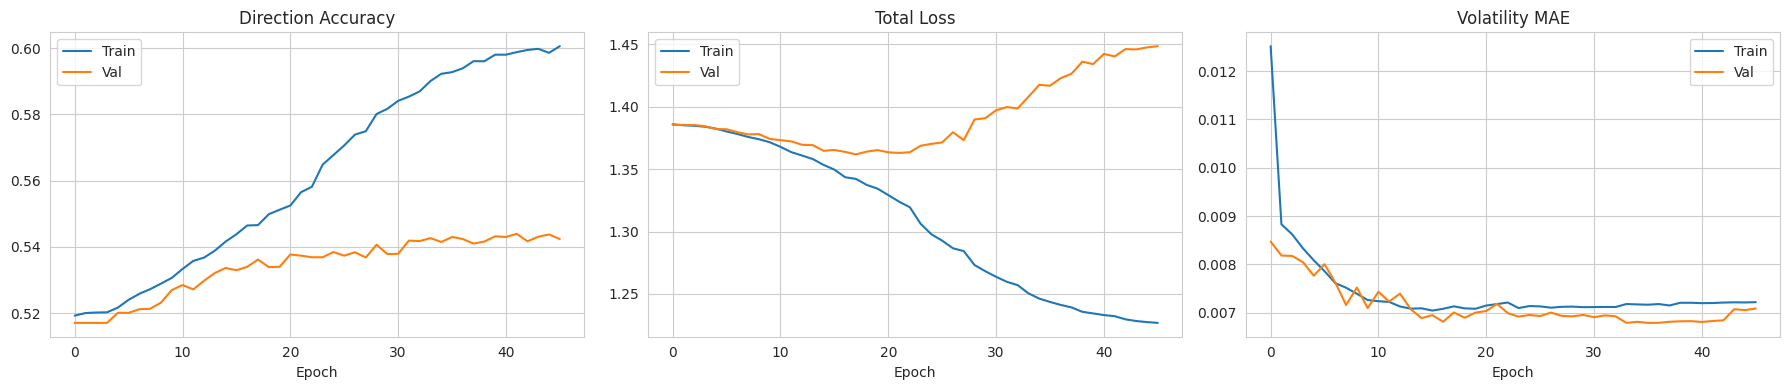

In [52]:
# ============================================================
# GRAPH 1 — TRAINING HISTORY
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history['dir_output_accuracy'], label='Train')
axes[0].plot(history.history['val_dir_output_accuracy'], label='Val')
axes[0].set_title('Direction Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Total Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['vol_output_mae'], label='Train')
axes[2].plot(history.history['val_vol_output_mae'], label='Val')
axes[2].set_title('Volatility MAE')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

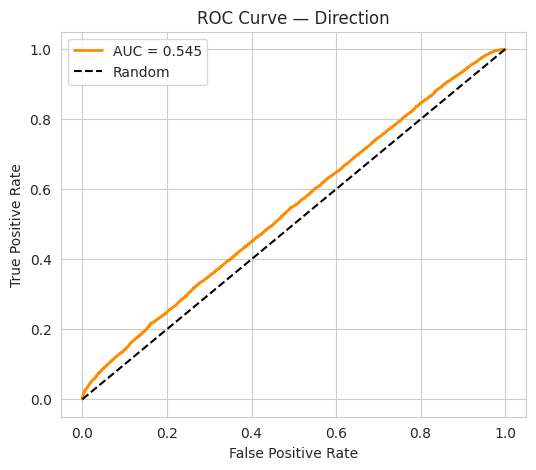

In [53]:
# ============================================================
# GRAPH 2 — ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(d_true, d_pred.flatten())
auc = roc_auc_score(d_true, d_pred.flatten())

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Direction')
plt.legend()
plt.show()

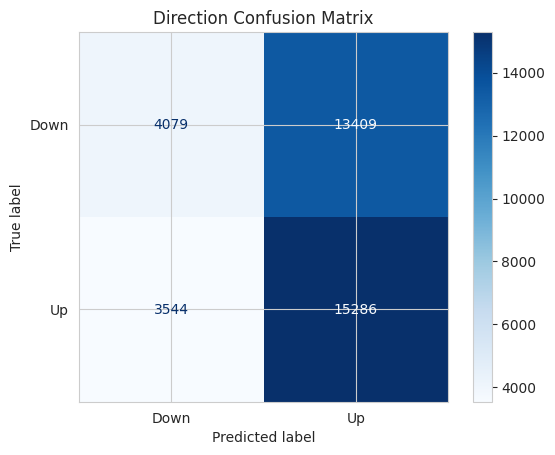

In [54]:
# ============================================================
# GRAPH 3 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(d_true, d_pred_binary)
disp = ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up'])
disp.plot(cmap='Blues')
plt.title('Direction Confusion Matrix')
plt.show()

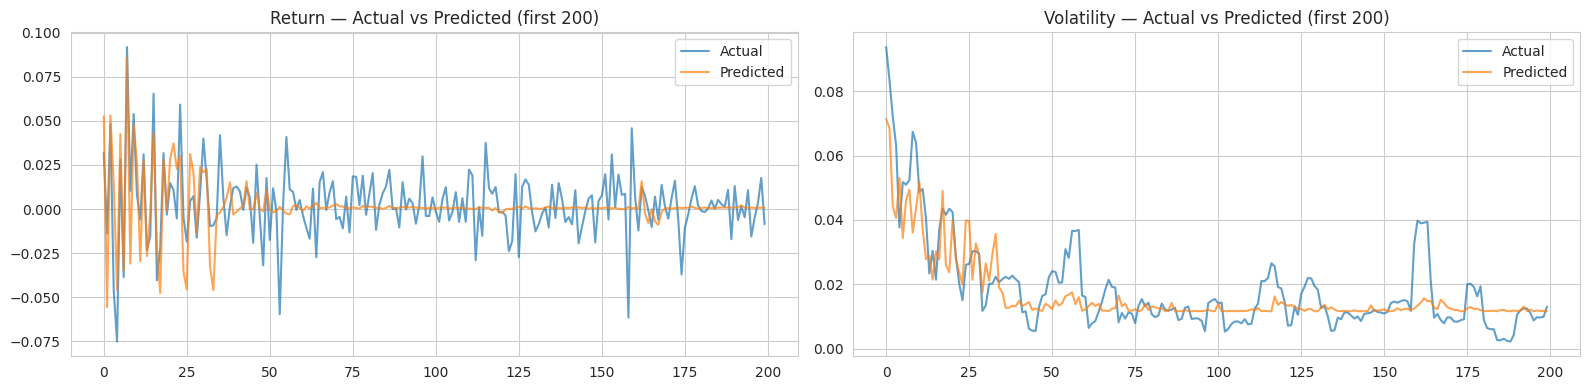

In [55]:
# ============================================================
# GRAPH 4 — PREDICTED VS ACTUAL (RETURN & VOLATILITY)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(yts_r[:200], label='Actual', alpha=0.7)
axes[0].plot(r_pred[:200], label='Predicted', alpha=0.7)
axes[0].set_title('Return — Actual vs Predicted (first 200)')
axes[0].legend()

axes[1].plot(yts_v[:200], label='Actual', alpha=0.7)
axes[1].plot(v_pred[:200], label='Predicted', alpha=0.7)
axes[1].set_title('Volatility — Actual vs Predicted (first 200)')
axes[1].legend()

plt.tight_layout()
plt.show()

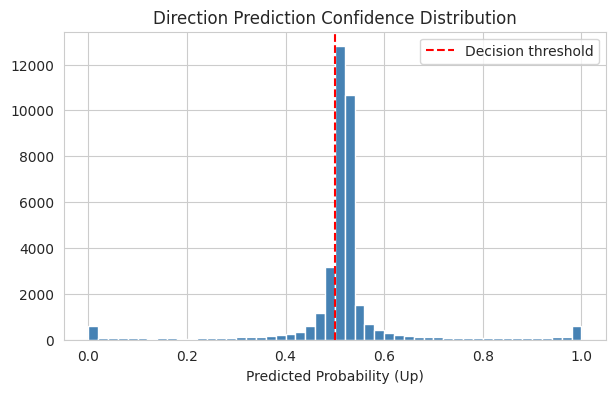

In [56]:
# ============================================================
# GRAPH 5 — PREDICTION CONFIDENCE DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 4))
plt.hist(d_pred.flatten(), bins=50, color='steelblue', edgecolor='white')
plt.axvline(0.5, color='red', linestyle='--', label='Decision threshold')
plt.xlabel('Predicted Probability (Up)')
plt.title('Direction Prediction Confidence Distribution')
plt.legend()
plt.show()